In [1]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df=pd.read_csv(
"../data/processed/clean_data.csv"
)

df.head()

,title,tags_x,genre,popularity,vote_count,vote_average
0,my little pony: a new generation,"robert cullen, josé lui ucha vanessa hudgens, ...","Animation, Family, Fantasy, Comedy, Music, Adv...",137.815,190.0,popular
1,the starling,"theodor melfi melissa mccarthy, chri o'dowd, k...",Drama,27.515,174.0,popular
2,je suis karl,"christian schwochow luna wedler, janni niewöhn...",Drama,19.294,20.0,not_popular
3,confessions of an invisible girl,"bruno garotti klara castanho, lucca picon, júl...","Comedy, Drama",62.097,144.0,average
4,intrusion,"adam salki freida pinto, logan marshall-green,...",Thriller,60.475,412.0,below_avg


In [3]:
print(df.shape)

print(df.columns)


(1726, 6)
Index(['title', 'tags_x', 'genre', 'popularity', 'vote_count', 'vote_average'], dtype='str')


# feature selection

In [4]:
# input feature
features=[

'vote_count',

'vote_average'

]

In [5]:
# target
target='popularity'
x=df[features]

y=df[target]

# check missing values

In [6]:
print(
x.isnull().sum()
)

print(
y.isnull().sum()
)

vote_count      0
vote_average    0
dtype: int64
0


In [7]:
# Numeric columns
num_cols = x.select_dtypes(include=['number']).columns
x[num_cols] = x[num_cols].fillna(x[num_cols].mean())

# Categorical columns
cat_cols = x.select_dtypes(include=['object']).columns
x[cat_cols] = x[cat_cols].fillna(x[cat_cols].mode().iloc[0])

C:\Users\thaku\AppData\Local\Temp\ipykernel_6876\2261633993.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x.select_dtypes(include=['object']).columns


In [8]:
# Fill text features
text_cols = ['overview', 'genres', 'keywords', 'cast', 'director']

for col in text_cols:
    if col in x.columns:
        x[col] = x[col].fillna('')

# Fill numeric features
num_cols = x.select_dtypes(include=['number']).columns
x[num_cols] = x[num_cols].fillna(x[num_cols].median())

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Convert vote_average from string to numeric
x['vote_average'] = pd.to_numeric(
    x['vote_average'],
    errors='coerce'
)

# Fill missing values
x['vote_average'] = x['vote_average'].fillna(
    x['vote_average'].median()
)

x['vote_count'] = x['vote_count'].fillna(
    x['vote_count'].median()
)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(
    x_train,
    y_train
)

# Predictions
y_pred = model.predict(x_test)

print("Model trained successfully!")

Model trained successfully!


# model evaluate

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions
predictions = model.predict(x_test)

# Evaluation metrics
mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

MAE: 22.876006289081985
MSE: 2411.221850035079
R2: -1.1249469492013202


# Compare Actual VS Predicted 

In [11]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

comparison['Error'] = (
    comparison['Actual'] - comparison['Predicted']
).abs()

comparison.head(10)

,Actual,Predicted,Error
0,19.305,77.953410,58.648410
1,15.398,31.194623,15.796623
2,28.473,42.994450,14.521450
3,66.957,56.194520,10.762480
4,66.867,34.558640,32.308360
5,22.029,65.331957,43.302957
6,110.146,28.235050,81.910950
7,15.191,16.734385,1.543385
8,23.391,38.922560,15.531560
9,29.055,34.487774,5.432774


# visualization

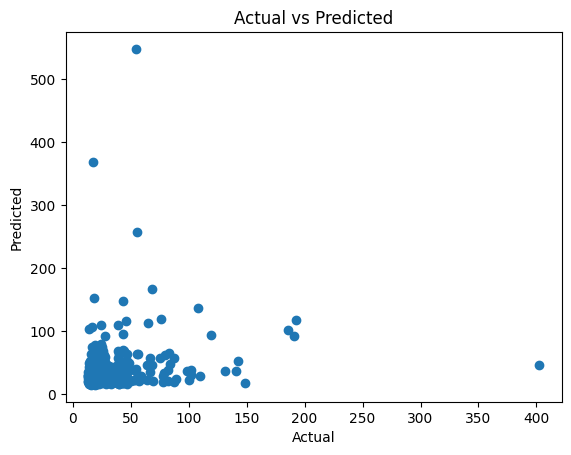

In [12]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
y_test,
predictions
)

plt.xlabel(
"Actual"
)

plt.ylabel(
"Predicted"
)

plt.title(
"Actual vs Predicted"
)

plt.show()

In [13]:
pickle.dump(

model,

open(

"../models/popularity_model.pkl",

"wb"

)

)

In [14]:
import shutil

shutil.rmtree("models")
print("models folder deleted")

models folder deleted
